<a href="https://colab.research.google.com/github/othman787/hello-world/blob/master/Tadawul_Financial_Analytics_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python for Finance — Companion Notebook
**Data:** `tadawul_merged.csv` — Tadawul-listed company financials, 2006–2026 (annual).
Includes income statement, balance sheet, cash flow, and company profile (name, sector) columns — 161 columns in total.

This notebook mirrors the course slides, using your real uploaded data, with real (not simulated) outputs baked in.


## Day 1 (AM) — Load & Inspect

Uploading Files to Colab

YouThere are several ways to upload files to your Google Colab environment:

1.  **Using the File Browser (manual upload):**
    *   On the left sidebar, click on the folder icon to open the file browser.
    *   Click on the "Upload to session storage" icon (a page with an arrow pointing up).
    *   Select your `tadawul_merged.csv` file from your local machine.
    *   **Note:** Files uploaded this way are temporary and will be deleted when your Colab session ends.

2.  **Using `files.upload()` (programmatic upload):**
    *   Run the Python code below. It will display an "Upload" button.
    *   Click the button and select your `tadawul_merged.csv` file.
    *   This is also temporary, but useful for scripting.

3.  **Mounting Google Drive:**
    *   If your file is in Google Drive, you can mount your Drive to Colab. This provides more persistent storage.
    *   Run `from google.colab import drive; drive.mount('/content/drive')` and follow the authentication steps.
    *   Your files will then be accessible at `/content/drive/My Drive/your_file_path`.

For the immediate error, the quickest fix is usually to use the file browser or the `files.upload()` method.

In [1]:
from google.colab import files
import io

# This will open a file picker dialog for you to upload the file.
print("Please upload the 'tadawul_merged.csv' file.")
uploaded = files.upload()

# To verify the upload, you can print the keys (filenames) of the uploaded dictionary
for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Please upload the 'tadawul_merged.csv' file.


Saving tadawul_merged.csv to tadawul_merged.csv
User uploaded file "tadawul_merged.csv" with length 4730200 bytes


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# To load the file into a DataFrame after uploading with this method:
df = pd.read_csv("tadawul_merged.csv")

,ticker,fiscal_year,profile_name,profile_sector,revenue,net_income
0,1010,2006,Riyad Bank,Finance,5.169329e+09,2.908554e+09
1,1010,2007,Riyad Bank,Finance,5.831599e+09,3.011246e+09
2,1010,2008,Riyad Bank,Finance,6.506553e+09,2.638757e+09
3,1010,2009,Riyad Bank,Finance,5.789673e+09,3.030485e+09
4,1010,2010,Riyad Bank,Finance,6.104329e+09,2.824627e+09


In [4]:
df.head()

,ticker,fiscal_year,period_type,period_label,period_end_date,currency,profile_name,profile_sector,profile_industry,profile_ceo,...,decrease_in_capital_stock,other_financing_activities,cash_from_financing_activities,effect_of_foreign_exchange,net_change_in_cash,free_cash_flow,free_cash_flow_to_firm,free_cash_flow_to_equity,free_cash_flow_per_share,price_to_free_cash_flow
0,1010,2006,annual,FY,12/31/06,SAR,Riyad Bank,Finance,Major banks,Nadir Sami Al-Koraya,...,NaN,1.377120e+08,6.885600e+07,NaN,3.896808e+09,3.857137e+09,NaN,3.857196e+09,2.312449,5.440565
1,1010,2007,annual,FY,12/31/07,SAR,Riyad Bank,Finance,Major banks,Nadir Sami Al-Koraya,...,NaN,0.000000e+00,-1.987623e+09,NaN,9.177294e+09,1.094689e+10,NaN,1.094689e+10,6.568133,2.821227
2,1010,2008,annual,FY,12/31/08,SAR,Riyad Bank,Finance,Major banks,Nadir Sami Al-Koraya,...,NaN,1.312500e+10,1.092492e+10,NaN,-5.725532e+09,-2.981502e+09,NaN,-2.981502e+09,-0.745375,-10.665766
3,1010,2009,annual,FY,12/31/09,SAR,Riyad Bank,Finance,Major banks,Nadir Sami Al-Koraya,...,NaN,-2.014593e+09,-2.014593e+09,NaN,1.276886e+10,5.003879e+09,NaN,5.003879e+09,1.250970,8.063744
4,1010,2010,annual,FY,12/31/10,SAR,Riyad Bank,Finance,Major banks,Nadir Sami Al-Koraya,...,NaN,0.000000e+00,-2.059250e+09,NaN,-1.608233e+09,1.452523e+09,NaN,1.452523e+09,0.363131,27.469445


In [ ]:
df[["ticker", "fiscal_year", "profile_name", "profile_sector", "revenue", "net_income"]].head()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3977 entries, 0 to 3976
Columns: 161 entries, ticker to price_to_free_cash_flow
dtypes: float64(144), int64(2), object(15)
memory usage: 4.9+ MB


In [7]:
df.describe()

,ticker,fiscal_year,profile_founded,profile_number_of_employees,profile_reporting_calendar.current_fiscal_year,revenue,cost_of_goods_sold,gross_profit,other_operating_income,operating_expenses_total,...,decrease_in_capital_stock,other_financing_activities,cash_from_financing_activities,effect_of_foreign_exchange,net_change_in_cash,free_cash_flow,free_cash_flow_to_firm,free_cash_flow_to_equity,free_cash_flow_per_share,price_to_free_cash_flow
count,3977.000000,3977.000000,3955.000000,3907.000000,3972.000000,3.898000e+03,3.143000e+03,3.166000e+03,3.156000e+03,3.467000e+03,...,2.770000e+02,3.741000e+03,3.741000e+03,4.990000e+02,3.735000e+03,3.915000e+03,3.027000e+03,3.915000e+03,3914.000000,3541.000000
mean,4627.028162,2017.949208,1990.663717,3217.612234,2025.021903,7.052709e+09,4.398803e+09,3.591878e+09,7.065325e+06,9.062217e+08,...,-1.144955e+08,-2.574162e+07,-8.452552e+08,-1.574284e+07,9.965740e+07,1.477879e+09,1.095612e+09,1.651791e+09,0.252038,-303.476370
std,2725.897479,5.632654,19.679197,7975.392562,0.146386,7.633779e+10,3.728251e+10,4.902635e+10,3.002568e+08,8.549559e+09,...,4.965933e+08,2.150720e+09,1.667752e+10,2.335905e+08,3.250236e+09,2.378358e+10,5.533438e+10,2.299372e+10,45.713389,16205.966608
min,1010.000000,2006.000000,1830.000000,4.000000,2025.000000,-1.234514e+08,-1.221521e+09,-1.755344e+09,-6.531827e+09,-4.230235e+09,...,-5.368353e+09,-4.241900e+10,-5.108690e+11,-9.975280e+08,-7.353200e+10,-8.587109e+10,-2.647120e+12,-8.586580e+10,-2839.838384,-710862.288200
25%,2250.000000,2014.000000,1979.000000,228.000000,2025.000000,1.676494e+08,1.034697e+08,3.732458e+07,0.000000e+00,2.195410e+07,...,-4.384700e+07,-3.805904e+07,-1.461380e+08,-5.050504e+06,-2.619463e+07,-1.070890e+07,-2.672845e+04,-2.498630e+06,-0.224578,-8.958196
50%,4110.000000,2019.000000,1992.000000,700.000000,2025.000000,6.537612e+08,4.659384e+08,1.522903e+08,0.000000e+00,7.173900e+07,...,-2.486670e+05,-2.750000e+06,-1.548846e+07,-1.244330e+05,5.721570e+05,3.158537e+07,5.798201e+07,3.797300e+07,0.526501,10.204674
75%,7020.000000,2023.000000,2006.000000,2800.000000,2025.000000,1.917684e+09,1.232601e+09,4.869600e+08,0.000000e+00,2.778930e+08,...,0.000000e+00,0.000000e+00,1.268475e+07,2.194885e+05,3.977820e+07,1.912563e+08,2.834510e+08,2.237214e+08,2.100801,23.390978
max,9651.000000,2026.000000,2022.000000,76664.000000,2026.000000,2.266370e+12,9.119160e+11,1.582150e+12,1.405813e+10,4.380760e+11,...,0.000000e+00,4.231676e+10,4.677867e+10,4.487827e+09,1.019100e+11,6.981520e+11,7.028050e+11,5.747200e+11,66.400505,281109.649000


In [8]:
df.shape

(3977, 161)

## Day 1 (AM) — Data Quality Check
Before any analysis: how big is this file, what type is every column, does it repeat itself,
what's missing, and does anything look like an outlier?

In [9]:
print("Shape:", df.shape)
dtype_counts = {str(k): int(v) for k, v in df.dtypes.value_counts().items()}
print("Column types:", dtype_counts)

print("\nExact duplicate rows:", df.duplicated().sum())
key_dupes = df.duplicated(subset=["ticker", "fiscal_year"])
print("Duplicate ticker+year rows:", key_dupes.sum())

Shape: (3977, 161)
Column types: {'float64': 144, 'object': 15, 'int64': 2}

Exact duplicate rows: 0
Duplicate ticker+year rows: 14


In [10]:
fully_empty = df.isna().all()
print("Completely empty columns:", fully_empty.sum())

cols = ["revenue", "bs_total_equity"]
(df[cols] / 1e9).describe().loc[["min", "50%", "max"]].round(2)

Completely empty columns: 21


,revenue,bs_total_equity
min,-0.12,-1.47
50%,0.65,0.71
max,2266.37,1737.09


In [18]:
# maybe have students do this.
print("Column Name | Non-Missing Rows | Coverage (%)")

print("--------------------------------------------------")
for col in df.columns:
    non_missing_count = df[col].count()
    total_rows = df.shape[0]
    coverage_percentage = (non_missing_count / total_rows) * 100
    print(f"{col:<20} | {non_missing_count:<17} | {coverage_percentage:.2f}%")

Column Name | Non-Missing Rows | Coverage (%)
--------------------------------------------------
ticker               | 3977              | 100.00%
fiscal_year          | 3977              | 100.00%
period_type          | 3974              | 99.92%
period_label         | 3974              | 99.92%
period_end_date      | 3977              | 100.00%
currency             | 3974              | 99.92%
profile_name         | 3977              | 100.00%
profile_sector       | 3977              | 100.00%
profile_industry     | 3977              | 100.00%
profile_ceo          | 3914              | 98.42%
profile_founded      | 3955              | 99.45%
profile_website      | 3977              | 100.00%
profile_number_of_employees | 3907              | 98.24%
profile_short_description | 3977              | 100.00%
profile_address.city | 3977              | 100.00%
profile_address.country | 3977              | 100.00%
profile_ipo.date     | 3977              | 100.00%
profile_reporting_calendar.

In [16]:
# a peek at the actual duplicate rows
dupe_mask = df.duplicated(subset=["ticker", "fiscal_year"], keep=False)
df[dupe_mask].sort_values(["ticker", "fiscal_year"])[
    ["ticker", "fiscal_year", "period_end_date", "revenue", "bs_total_equity"]
].head(28)

,ticker,fiscal_year,period_end_date,revenue,bs_total_equity
1870,4070,2010,12/31/10,1.539037e+08,2.627600e+08
1871,4070,2010,3/31/10,1.177630e+08,2.269660e+08
1872,4070,2011,12/31/11,1.216812e+08,2.345169e+08
1873,4070,2011,3/31/11,NaN,2.486640e+08
1961,4100,2011,3/31/11,NaN,3.442204e+09
1962,4100,2011,4/30/11,3.239952e+08,3.442204e+09
1963,4100,2012,1/31/12,NaN,NaN
1964,4100,2012,3/31/12,NaN,3.747929e+09
1965,4100,2012,4/30/12,3.682287e+08,3.747929e+09
1966,4100,2013,1/31/13,NaN,NaN


In [17]:
df[df['ticker'].isin([4100, 4070, 4191,4240,4291,4335 ])]['profile_name'].unique()

array(['Tihama Advertising & Public Relations Co.',
       'Makkah Construction & Development Co.',
       'Abdullah Saad Mohammed Abo Moati for Bookstores Co.',
       'AFG International Company',
       'National Co. for Learning & Education', 'Musharaka REIT Fund'],
      dtype=object)

## Students work

In [19]:
columns_to_analyze = [
    "decrease_in_capital_stock",
    "effect_of_foreign_exchange",
    "cash_from_divestitures"
]

print("--- Missing Values and Descriptive Statistics ---")
for col in columns_to_analyze:
    missing_count = df[col].isnull().sum()
    total_count = df.shape[0]
    missing_percentage = (missing_count / total_count) * 100

    print(f"\nColumn: {col}")
    print(f"  Missing Values: {missing_count} ({missing_percentage:.2f}%)")
    if missing_count < total_count: # Only calculate stats if there's actual data
        print(f"  Min: {df[col].min():.2f}")
        print(f"  Median: {df[col].median():.2f}")
        print(f"  Max: {df[col].max():.2f}")
    else:
        print("  No non-missing data to calculate min/median/max.")

--- Missing Values and Descriptive Statistics ---

Column: decrease_in_capital_stock
  Missing Values: 3700 (93.03%)
  Min: -5368352880.00
  Median: -248667.00
  Max: 0.00

Column: effect_of_foreign_exchange
  Missing Values: 3478 (87.45%)
  Min: -997528000.00
  Median: -124433.00
  Max: 4487827000.00

Column: cash_from_divestitures
  Missing Values: 3559 (89.49%)
  Min: -22168000.00
  Median: 1016130.00
  Max: 30116000000.00


In [20]:
def column_report(df, columns_to_analyze):
    """
    Reports missing values and descriptive statistics (min, median, max)
    for a given list of columns in a DataFrame.

    Args:
        df (pd.DataFrame): The input DataFrame.
        columns_to_analyze (list): A list of column names to analyze.
    """
    print("--- Missing Values and Descriptive Statistics ---")
    for col in columns_to_analyze:
        missing_count = df[col].isnull().sum()
        total_count = df.shape[0]
        missing_percentage = (missing_count / total_count) * 100

        print(f"\nColumn: {col}")
        print(f"  Missing Values: {missing_count} ({missing_percentage:.2f}%)")
        # Only calculate stats if there's actual non-missing data
        if missing_count < total_count:
            print(f"  Min: {df[col].min():.2f}")
            print(f"  Median: {df[col].median():.2f}")
            print(f"  Max: {df[col].max():.2f}")
        else:
            print("  No non-missing data to calculate min/median/max.")

# Example usage with the same columns as before:
# column_report(df, ["decrease_in_capital_stock", "effect_of_foreign_exchange", "cash_from_divestitures"])

In [21]:
column_report(df, ["revenue"])

--- Missing Values and Descriptive Statistics ---

Column: revenue
  Missing Values: 79 (1.99%)
  Min: -123451429.00
  Median: 653761175.50
  Max: 2266370000000.00


## Day 1 (PM) — Select, Filter, Groupby, Chart

In [23]:
# .loc selects by label
df.loc[:, "revenue"]

,revenue
0,5.169329e+09
1,5.831599e+09
2,6.506553e+09
3,5.789673e+09
4,6.104329e+09
...,...
3972,7.109870e+08
3973,1.660051e+08
3974,1.976459e+08
3975,1.244074e+08


In [ ]:
# boolean filter: firms in the Finance sector
finance = df[df["profile_sector"] == "Finance"]
finance.shape

(1121, 161)

In [ ]:
# groupby: average revenue by sector, most recent year
avg_by_sector = (
    df[df["fiscal_year"] == 2024]
    .groupby("profile_sector")["revenue"]
    .mean()
    .sort_values(ascending=False)
)
avg_by_sector.head(6).round(0)

profile_sector
Energy minerals       6.167893e+11
Communications        1.764635e+10
Utilities             1.753389e+10
Process industries    5.336563e+09
Finance               2.780314e+09
Retail trade          2.739822e+09
Name: revenue, dtype: float64

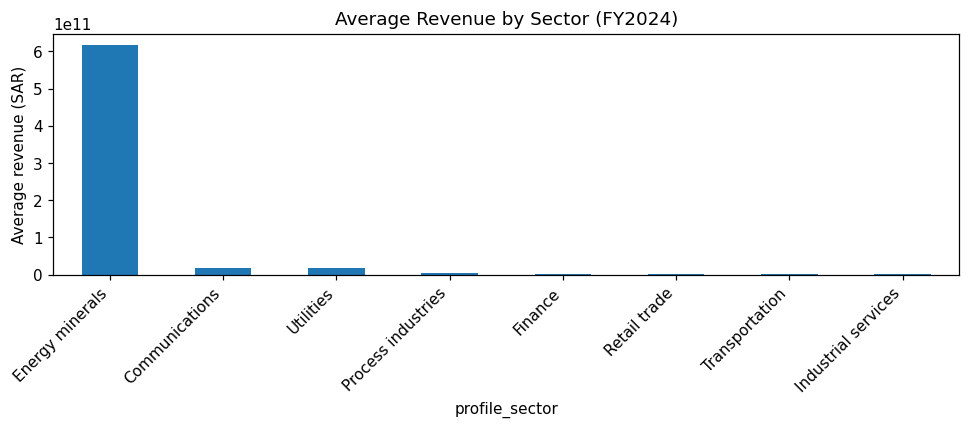

In [ ]:
avg_by_sector.head(8).plot(kind="bar", title="Average Revenue by Sector (FY2024)", figsize=(9,4))
plt.ylabel("Average revenue (SAR)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Day 2 (AM) — Reshaping & the Firm × Year Index

In [ ]:
# pivot_table: revenue by ticker x year, for a handful of tickers
sample_tickers = [1010, 1020, 1030, 1050, 1060]
wide_view = df[df["ticker"].isin(sample_tickers)].pivot_table(
    index="ticker", columns="fiscal_year", values="revenue"
)
wide_view.iloc[:, -5:].round(0)

fiscal_year          2021          2022  ...          2024          2025
ticker                                   ...                            
1010         1.157557e+10  1.332814e+10  ...  1.725250e+10  1.835413e+10
1020         3.546884e+09  3.429643e+09  ...  3.779125e+09  4.462516e+09
1030         2.758248e+09  3.281043e+09  ...  4.163871e+09  4.778483e+09
1050         7.244825e+09  8.021256e+09  ...  9.621734e+09  1.048595e+10
1060         7.683267e+09  9.654205e+09  ...  1.413614e+10  1.484161e+10

[5 rows x 5 columns]

In [ ]:
# multi-index: ticker x fiscal_year -- slice one firm's full history
panel = df.set_index(["ticker", "fiscal_year"]).sort_index()
panel.loc[1010, ["profile_name", "revenue", "net_income"]].tail(5)

            profile_name       revenue    net_income
fiscal_year                                         
2021          Riyad Bank  1.157557e+10  6.025379e+09
2022          Riyad Bank  1.332814e+10  7.019322e+09
2023          Riyad Bank  1.575874e+10  8.045844e+09
2024          Riyad Bank  1.725250e+10  9.321894e+09
2025          Riyad Bank  1.835413e+10  1.041095e+10

## Day 2 (PM) — Financial Ratios (now with ROE & ROA)

In [ ]:
import numpy as np

# same real-data guard as before: a handful of firm-years have revenue <= 0,
# which would silently produce inf and poison any .mean()/.std() downstream
print("Firm-years with revenue <= 0:", (df["revenue"] <= 0).sum())
df.loc[df["revenue"] <= 0, "revenue"] = np.nan

df["net_margin"] = df["net_income"] / df["revenue"]
df["roe"] = df["net_income"] / df["bs_total_equity"]
df["roa"] = df["net_income"] / df["bs_tot_asset"]

df[["net_margin", "roe", "roa"]].describe().round(3)

Firm-years with revenue <= 0: 32


       net_margin       roe       roa
count    3863.000  3836.000  3907.000
mean       -0.335     0.027     0.044
std        10.996     2.271     0.304
min      -491.387   -72.309   -11.565
25%         0.019     0.016     0.007
50%         0.100     0.085     0.038
75%         0.225     0.176     0.093
max        63.777    73.000    11.207

In [ ]:
# year-over-year revenue growth, per ticker (sort first, or this silently
# computes "growth" across DIFFERENT firms at the year boundary)
df = df.sort_values(["ticker", "fiscal_year"])
df["revenue_growth"] = df.groupby("ticker")["revenue"].pct_change()
df[df["ticker"] == 1010][["fiscal_year", "revenue", "revenue_growth"]].tail(5).round(3)

    fiscal_year       revenue  revenue_growth
15         2021  1.157557e+10           0.044
16         2022  1.332814e+10           0.151
17         2023  1.575874e+10           0.182
18         2024  1.725250e+10           0.095
19         2025  1.835413e+10           0.064

In [ ]:
# hand-verify one row before trusting the column
row = df[(df["ticker"] == 1010) & (df["fiscal_year"] == 2024)].iloc[0]
manual_roe = row["net_income"] / row["bs_total_equity"]
print("Hand-check ROE, Riyad Bank FY2024:", round(manual_roe, 4))
print("Column value:                    ", round(row["roe"], 4))

Hand-check ROE, Riyad Bank FY2024: 0.1363
Column value:                     0.1363


## Day 3 (AM) — Peer Comparison & Correlation
Real sector data (`profile_sector`) means peer groups can now be sector-based, not just size-based.

In [ ]:
latest = df[df["fiscal_year"] == 2024].copy()
my_ticker = 1010
my_row = latest[latest["ticker"] == my_ticker].iloc[0]

peers = latest[
    (latest["profile_sector"] == my_row["profile_sector"]) &
    (latest["revenue"].between(my_row["revenue"] * 0.5, my_row["revenue"] * 2))
]
peers[["profile_name", "revenue", "roe"]].sort_values("roe", ascending=False).round(3)

                                   profile_name       revenue    roe
3082          Company for Cooperative Insurance  1.662809e+10  0.228
3368  Bupa Arabia for Cooperative Insurance Co.  1.879432e+10  0.228
144                               Al Rajhi Bank  3.191274e+10  0.160
182                                 Alinma Bank  1.093416e+10  0.141
18                                   Riyad Bank  1.725250e+10  0.136
118                          Arab National Bank  9.396234e+09  0.128
98                             Saudi Awwal Bank  1.413614e+10  0.116
78                          Banque Saudi Fransi  9.621734e+09  0.096

In [ ]:
ratio_cols = ["net_margin", "roe", "roa", "revenue_growth"]
latest[ratio_cols].corr().round(2)

                net_margin   roe   roa  revenue_growth
net_margin            1.00  0.41  0.45            0.20
roe                   0.41  1.00  0.88            0.19
roa                   0.45  0.88  1.00            0.19
revenue_growth        0.20  0.19  0.19            1.00

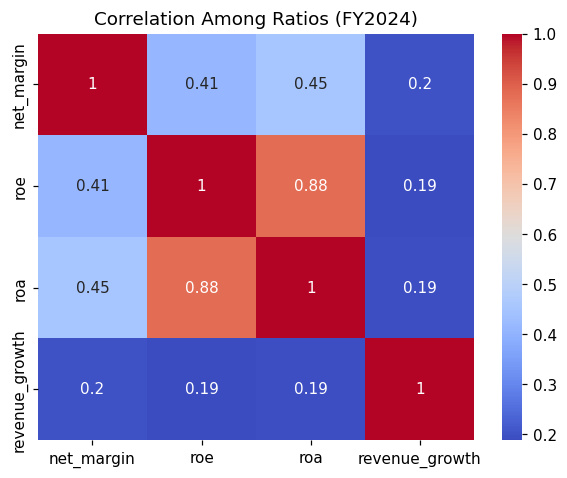

In [ ]:
import seaborn as sns
sns.heatmap(latest[ratio_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Among Ratios (FY2024)")
plt.show()

## Day 3 (PM) — Trend Charts

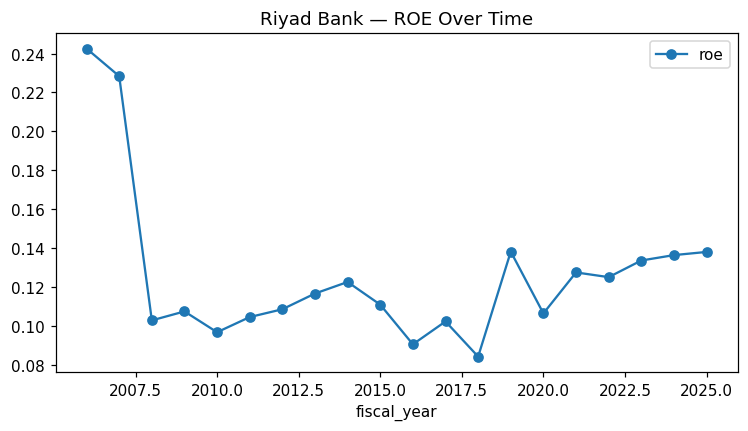

In [ ]:
one = df[df["ticker"] == 1010].sort_values("fiscal_year")
one.plot(x="fiscal_year", y="roe", marker="o", title="Riyad Bank — ROE Over Time", figsize=(8,4))
plt.show()

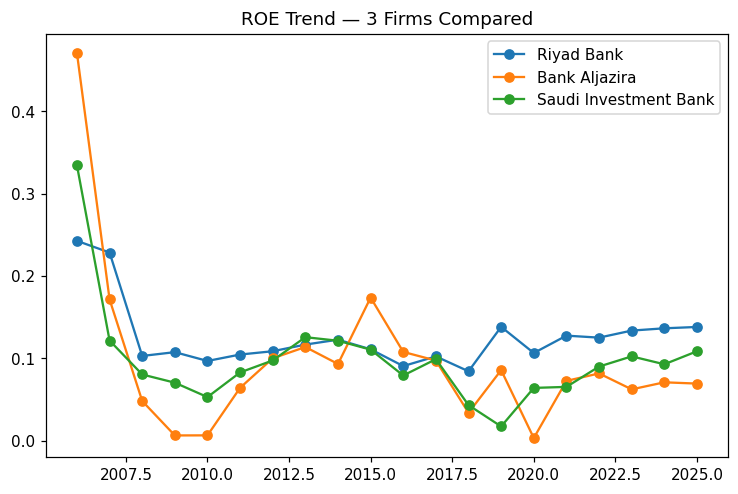

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
for t in [1010, 1020, 1030]:
    d = df[df["ticker"] == t].sort_values("fiscal_year")
    name = d["profile_name"].iloc[-1]
    ax.plot(d["fiscal_year"], d["roe"], marker="o", label=name)
ax.legend()
ax.set_title("ROE Trend — 3 Firms Compared")
plt.show()

## Day 4 (AM) — Screener: Normalize & Score
Composite score now includes ROE, since the balance sheet is available in this file.

In [ ]:
screen = df[df["fiscal_year"] == 2024].copy()
screen = screen.dropna(subset=["roe", "net_margin", "revenue_growth"])

for col in ["roe", "net_margin", "revenue_growth"]:
    screen[col + "_z"] = (screen[col] - screen[col].mean()) / screen[col].std()

screen["quality_score"] = (
    0.4 * screen["roe_z"] +
    0.4 * screen["net_margin_z"] +
    0.2 * screen["revenue_growth_z"]
)
screen.sort_values("quality_score", ascending=False)[
    ["profile_name", "profile_sector", "quality_score"]
].head(10)

                             profile_name       profile_sector  quality_score
590                          Savola Group   Process industries       3.145691
1058   Modern Mills for Food Products Co.   Process industries       1.313474
747         Saudi Advanced Industries Co.              Finance       1.306310
3971          Jamjoom Fashion Trading Co.         Retail trade       1.187320
1955             Taiba Investment Company    Consumer durables       1.044392
1895                    MBC Group Company    Consumer services       1.040849
827            Saudi Arabian Amiantit Co.  Non-energy minerals       0.998905
3350            Saudi Reinsurance Company              Finance       0.956951
3018  Etihad Atheeb Telecommunication Co.       Communications       0.906233
3823                 Armah Sports Company    Consumer Cyclical       0.900633

---
### Notes for extending this notebook
- `num_of_employees` and several detailed balance-sheet sub-items are mostly empty in this file — check before relying on them.
- The 14 duplicate ticker+year rows (different `period_end_date`) should be resolved (e.g., keep the latest-filed one) before any aggregate calculation that sums across all rows.
- All ratios here use FY2024 as the "latest" snapshot — change the year filter to re-run any section on a different year.
